In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
warnings.filterwarnings(action='ignore')

# Data Preprocessing

In [2]:
def compute_dtype(df):
    return df.dtypes
def compute_nunique(df):
    return df.nunique()
def compute_null_percentage(df):
    return (df.isnull().mean() * 100)

In [3]:
def numerical_data(df):
    return df.select_dtypes(include=['number']).columns

In [4]:
def categorical_data(df, threshold = 5):
    return [feature for feature in df.columns
          if df[feature].nunique()<=threshold ]

In [5]:
def str_data(df):
    return df.select_dtypes(include=['object']).columns

In [6]:
#Used for categorical variables.
def fill_na_mode(df):
    str_col=str_data(df)
    for feature in str_col:
        mode=df[feature].mode()[0]
        df[feature].fillna(mode, inplace=True)
    return df

In [7]:
#Better for skewed distributions or data with outliers.
def fill_na_median(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        median=df[feature].median()
        df[feature].fillna(median, inplace=True)
    return df

In [8]:
#Suitable for symmetric (normal) distributions without outliers.
def fill_na_mean(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        mean=df[feature].mean()
        df[feature].fillna(mean, inplace=True)
    return df

In [9]:
def is_null(df):
    return df.isnull().sum()

In [10]:
def drop_null_all_row(df):
    df.dropna(how='any',inplace=True)
    return df

In [11]:
def drop_null_row(df,columns):
    df.dropna(subset=[columns],inplace=True)
    return df

In [12]:
def is_duplicate(df):
    return df.duplicated().sum()

In [13]:
def remove_duplicate(df):
    df.drop_duplicates(inplace = True) 

# EDA

In [14]:
def plot_hist(df,x,xlabel,title,palette):
    plt.figure(figsize=(8, 5))
    sns.histplot(df[x], palette=palette)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Freq')
    plt.show()

In [15]:
def plot_bar(df,x,y,title,palette):
    plt.figure(figsize=(8, 5))
    sns.barplot(x=x,y=y,data=df,palette=palette)
    plt.title(title)
    plt.show()

In [16]:
def plot_pie(df,x,xlabel,ylabel,title,palette):
    plt.figure(figsize=(8, 5))
    plt.pie(df[x].unique(),labels=df[x].unique(),autopct="%1.1f%%", palette=palette)
    plt.title(title)
    plt.show()

In [17]:
def plot_box(df,x,palette):
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=x, data=df, palette=palette)
    plt.title('Box Plot')
    plt.show()

In [18]:
def plot_scatter(x,y,z,xlabel,ylabel,title):
    plt.scatter(x, y,c=z,alpha=0.5,marker='o',s = 30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


# Feature Engineering 

## 1.Numerical Feature Engineering 

### 1.1 Scalling

#### 1.1.1 Normalization 

##### Min-Max Scaling

In [19]:
def mm_scaler(df):
    numerical_col=numerical_data(df)
    scaler=MinMaxScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

##### Log normalization

In [20]:
def log_normal(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        negative_feature = df[feature] < 0
        df[feature] = np.log1p(np.abs(df[feature]))
        df[feature]=np.where(negative_feature,-df[feature],df[feature])
    return df 

#### 1.1.2 Standardization 

##### Z-Score Scaling

In [21]:
def z_scaler(df):
    numerical_col=numerical_data(df)
    scaler=StandardScaler()
    for feature in numerical_col:
        df[feature]=scaler.fit_transform(df[[feature]])
    return df 

### 1.2 Discretization

In [22]:
def bin_numerical_features(df, bins=10):
    numerical_col = numerical_data(df)
    for feature in numerical_col:
        df[feature + '_binned'] = pd.cut(df[feature], bins=bins, labels=False)
    return df

### 1.3 Descriptive Feature

#### 1.3.1 Skewness

In [23]:
#Positive Skew-->(mean > median)
#Negative Skew-->(mean < median)
#Zero Skewness-->Symmetrical distribution (mean ≈ median) Normal distribution 

In [24]:
#Log or Square Root Transformation (Best for Right Skew)
#Squaring (Best for Negative Skew)
def skewness(df):
    numerical_col=numerical_data(df)
    df_skew=df[numerical_col].apply(lambda x:x.skew())
    df_skew = df_skew.sort_values(ascending=False)
    df_skew=df_skew.reset_index()
    df_skew.columns = ['Feature', 'SkewFactor']
    return df_skew

#### 1.2.3 Quantile and Precentiles

In [25]:
def quartiles(df):
    numerical_cols = numerical_data(df)
    return df[numerical_cols].quantile([0.25, 0.5, 0.75]).T

#### 1.3 Feature Transformation

In [26]:
def sqrt_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.sqrt(df[feature])
    return df 

In [27]:
def sq_transform(df):
    numerical_col=numerical_data(df)
    for feature in numerical_col:
        df[feature] = np.square(df[feature])
    return df 

In [28]:
def correlation(df,target):
    numerical_col=numerical_data(df)
    correlation_matrix = df[numerical_col].corr()
    correlation_target=correlation_matrix[target].sort_values(ascending=False)
    correlation_target=correlation_target.reset_index()
    correlation_target.columns=['feature','corr factor']
    return correlation_target

## 2.Categorical Feature Engineering

#### One-Hot Encoding.

In [29]:

def one_hot_encoding(df):
    str_col=categorical_data(df)
    df=pd.get_dummies(df,columns=str_col)
    return df

#### Label Encoding

In [30]:
def label_encoding(df):
    str_col=categorical_data(df)
    encoder=LabelEncoder()
    for feature in str_col:
        df[feature]=encoder.fit_transform(df[[feature]])
    return df

#### Ordinal Encoding

In [31]:
def ordinal_encode(df,str_col):
    encoder = OrdinalEncoder()
    df[str_col] = encoder.fit_transform(df[[str_col]])
    return df

# Imbalance Data Detection and Treatment


removing samples from the majority class (under-sampling)
or adding more examples from the minority class (over-sampling).

## 1.Random Oversampling
Random oversampling duplicates existing examples from the minority class with replacement.

In [32]:
from imblearn.over_sampling import RandomOverSampler

def random_over_sampling(x,y):
    ros = RandomOverSampler(random_state=0)
    x_resample,y_resample = ros.fit_resample(x, y)
    return x_resample,y_resample

## 2.Random Undersampling
random undersampling removes existing samples from the majority class. 

In [33]:
from imblearn.under_sampling import RandomUnderSampler

def random_under_sampling(x,y):
    ros = RandomUnderSampler(random_state=0)
    x_resample,y_resample = ros.fit_resample(x, y)
    return x_resample,y_resample

## 3.SMOTE (Over-sampling)
Generates synthetic samples for the minority class by 
Combining Original Examples Using KNN

In [34]:
from imblearn.over_sampling import SMOTE
def smote(x,y):
    smote=SMOTE()
    x_resample,y_resample=smote.fit_resample(x,y)
    return x_resample,y_resample

## 4.Tomek Links (Under-sampling)
remove examples from majority class that are too close to minority class

In [35]:
from imblearn.under_sampling import TomekLinks

def tomek_links(x,y):
    tomek = TomekLinks()
    x_resample,y_resample = tomek.fit_resample(x, y)
    return x_resample,y_resample


## 5.Borderline-SMOTE

In [36]:
from imblearn.over_sampling import BorderlineSMOTE

def borderline_smote(x, y):
    borderline_smote = BorderlineSMOTE()
    x_resampled, y_resampled = borderline_smote.fit_resample(x, y)
    return x_resampled, y_resampled

## 6.SMOTE-ENN

In [37]:
from imblearn.combine import SMOTEENN
def smote_enn(x,y):
    smote_enn = SMOTEENN(random_state=42)
    x_resampled, y_resampled = smote_enn.fit_resample(x, y)
    return x_resampled, y_resampled

## 7.SMOTE-Tomek 
(SMOTE + Tomek Links)


In [38]:
from imblearn.combine import SMOTETomek

def smote_tomek(x, y):
    smote_tomek = SMOTETomek()
    x_resampled, y_resampled = smote_tomek.fit_resample(x, y)
    return x_resampled, y_resampled

In [39]:
from sklearn.decomposition import PCA
def pca(x,n_componant):
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x)    
    return x_pca             

# Data : ecoli

In [40]:
from imblearn.datasets import fetch_datasets
data = fetch_datasets()['ecoli']
x, y = data['data'], data['target']  


In [41]:
x_pca_original=pca(x,2)

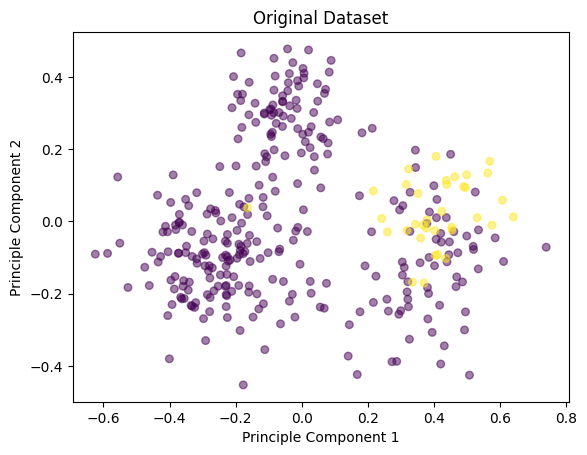

In [42]:
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')

In [43]:
x_resample,y_resample=random_over_sampling(x,y)


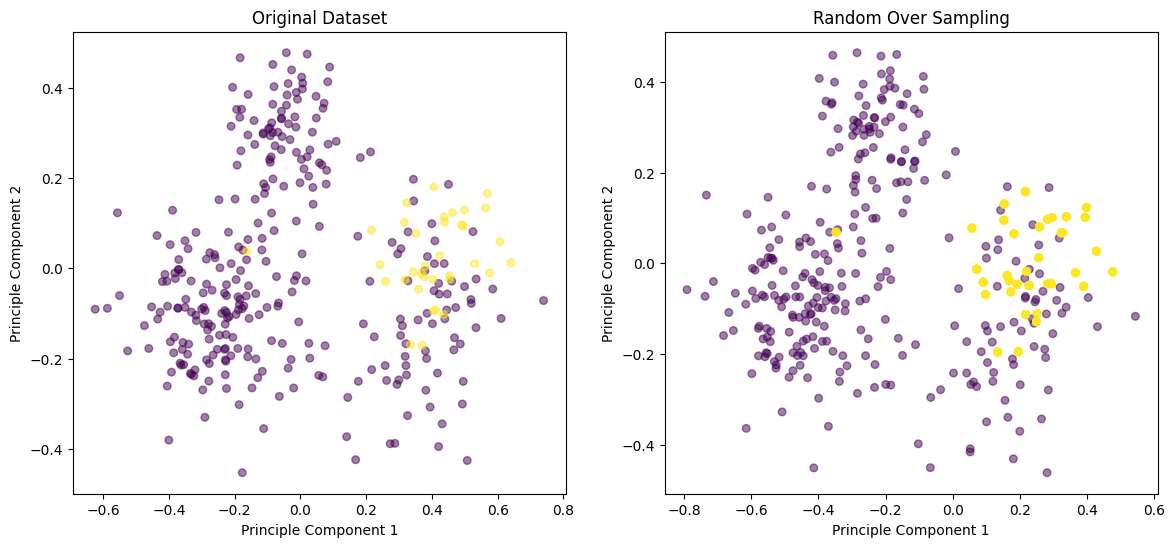

In [44]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','Random Over Sampling')


In [45]:
x_resample,y_resample=random_under_sampling(x,y)

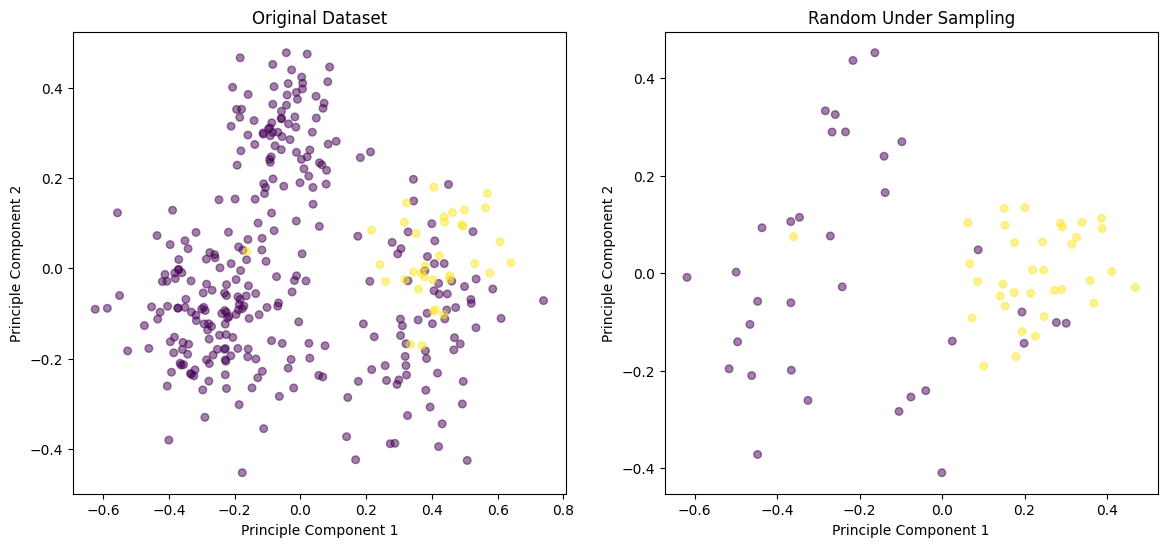

In [46]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','Random Under Sampling')


In [47]:
x_resample,y_resample=smote(x,y)

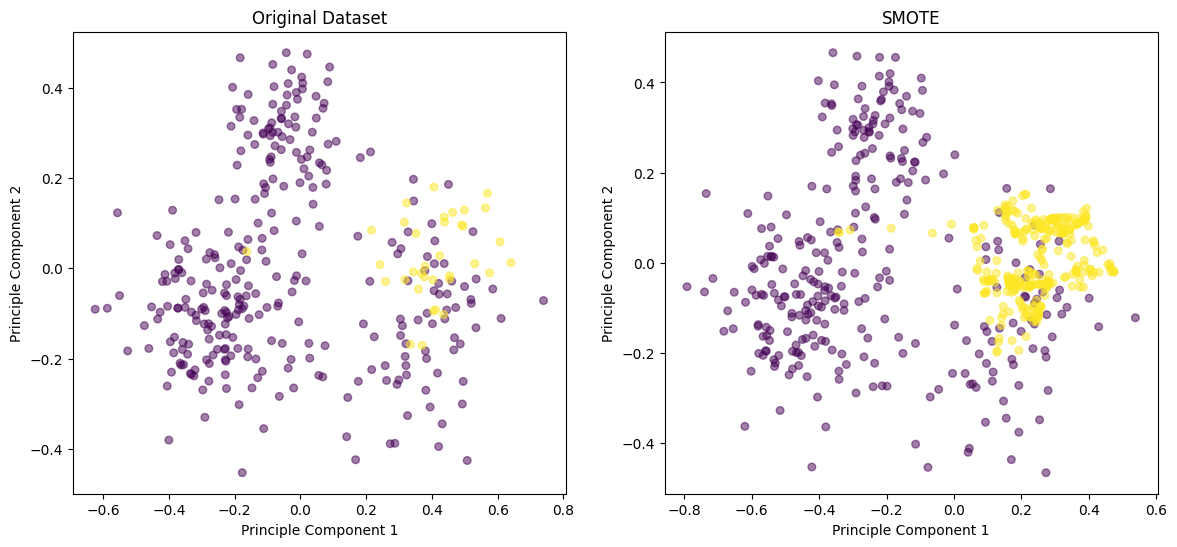

In [48]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','SMOTE')


In [49]:
x_resample,y_resample=tomek_links(x,y)

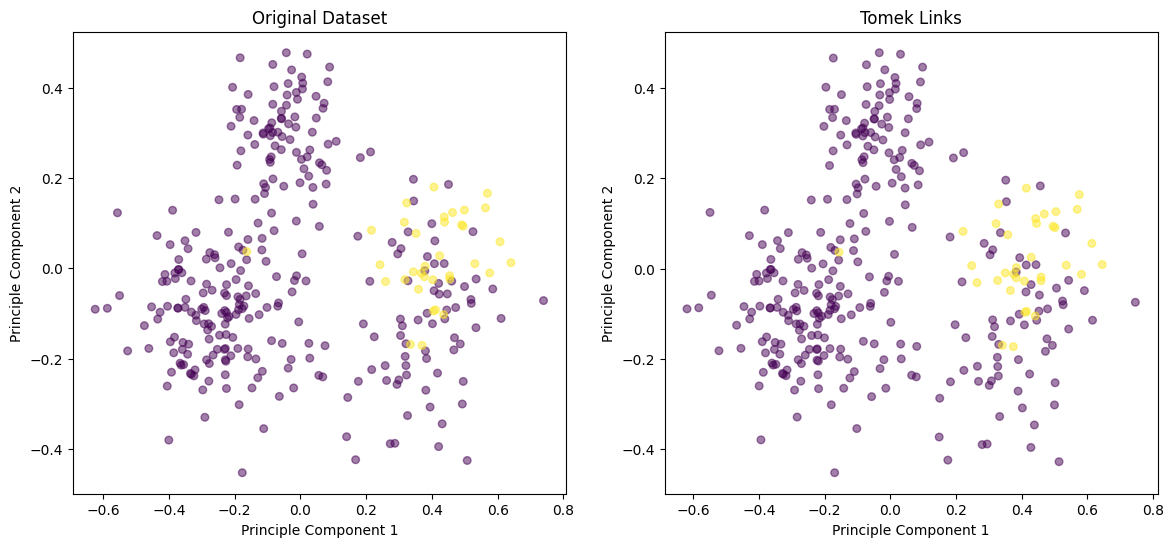

In [50]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','Tomek Links')


In [51]:
x_resample,y_resample=borderline_smote(x,y)

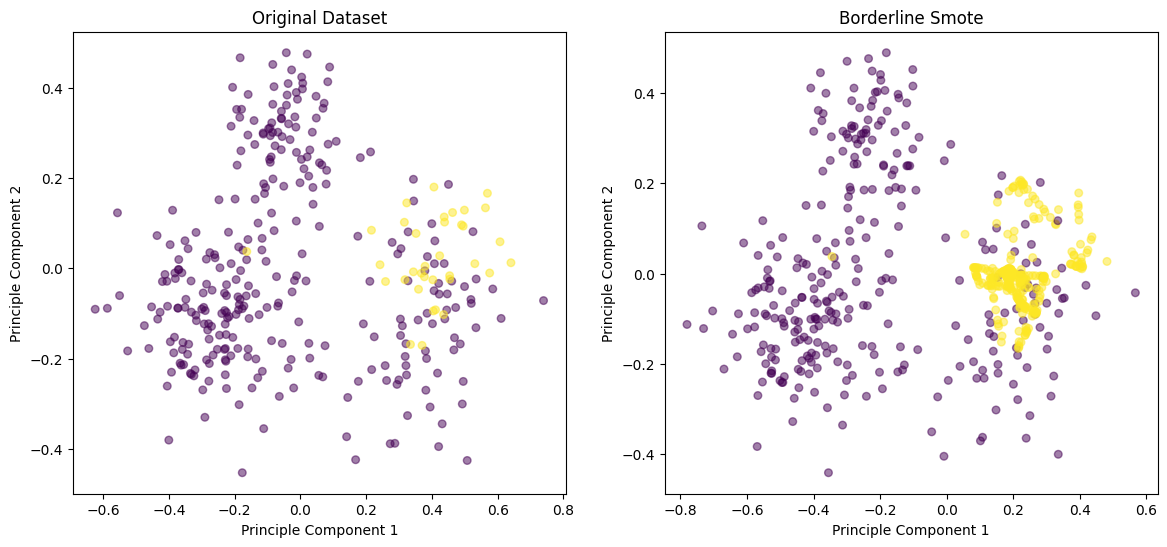

In [52]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','Borderline Smote')


In [53]:
x_resample,y_resample=smote_enn(x,y)

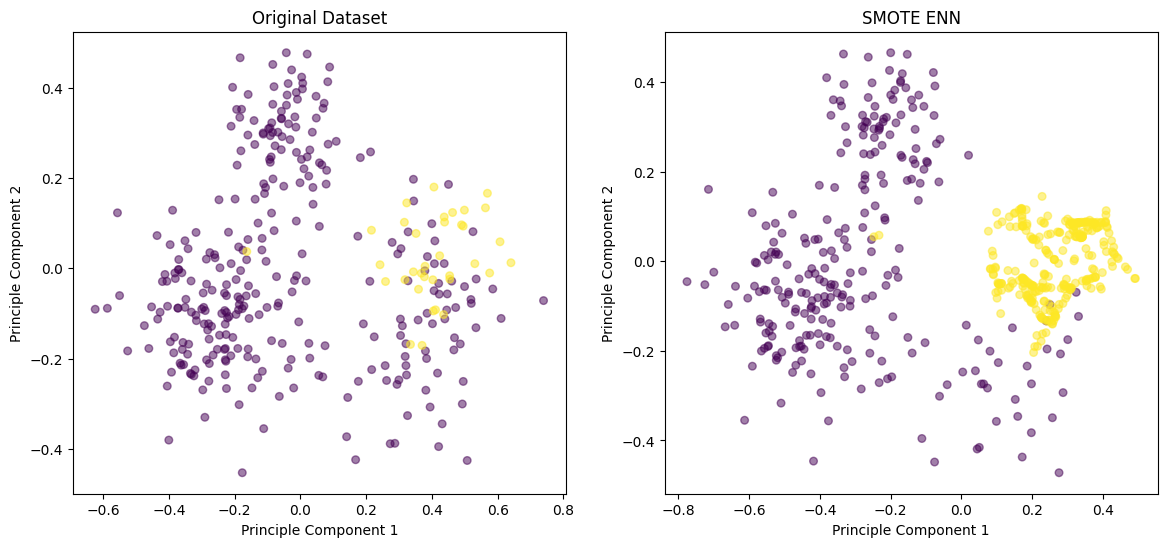

In [54]:
x_pca=pca(x_resample,2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plt.sca(axes[0])
plot_scatter(x_pca_original[:,0],x_pca_original[:,1],y,'Principle Component 1','Principle Component 2','Original Dataset')
plt.sca(axes[1])
plot_scatter(x_pca[:,0],x_pca[:,1],y_resample,'Principle Component 1','Principle Component 2','SMOTE ENN')
